In [1]:
##zadanie 1

import pandas as pd
import pyarrow

pliki = [
    '0000.parquet', '0001.parquet', '0002.parquet',
    '0003.parquet', '0004.parquet', '0005.parquet'
]

lista_kawalow = []

for plik in pliki:
    df_temp = pd.read_parquet(plik)
    lista_kawalow.append(df_temp)

df = pd.concat(lista_kawalow, ignore_index=True)

print("info o ramce")
df.info()
print("\n" + "="*50 + "\n")

pamiec_bajty = df.memory_usage(deep=True).sum()

pamiec_mb = pamiec_bajty / (1024 * 1024)

print(f"Całkowite zużycie pamięci RAM: {pamiec_mb:.2f} MB")

info o ramce
<class 'pandas.DataFrame'>
RangeIndex: 6884148 entries, 0 to 6884147
Data columns (total 17 columns):
 #   Column               Dtype
---  ------               -----
 0   sid                  int64
 1   sid_profile          int64
 2   post_id              str  
 3   profile_id           int64
 4   date                 str  
 5   post_type            int64
 6   description          str  
 7   likes                int64
 8   comments             int64
 9   username             str  
 10  bio                  str  
 11  following            int64
 12  followers            int64
 13  num_posts            int64
 14  is_business_account  bool 
 15  lang                 str  
 16  category             str  
dtypes: bool(1), int64(9), str(7)
memory usage: 2.9 GB


Całkowite zużycie pamięci RAM: 2945.77 MB


Optymalizacja
Stare zużycie pamięci: 2945.77 MB
Nowe zużycie pamięci:  2715.99 MB
Udało się zaoszczędzić: 229.78 MB (7.80%)


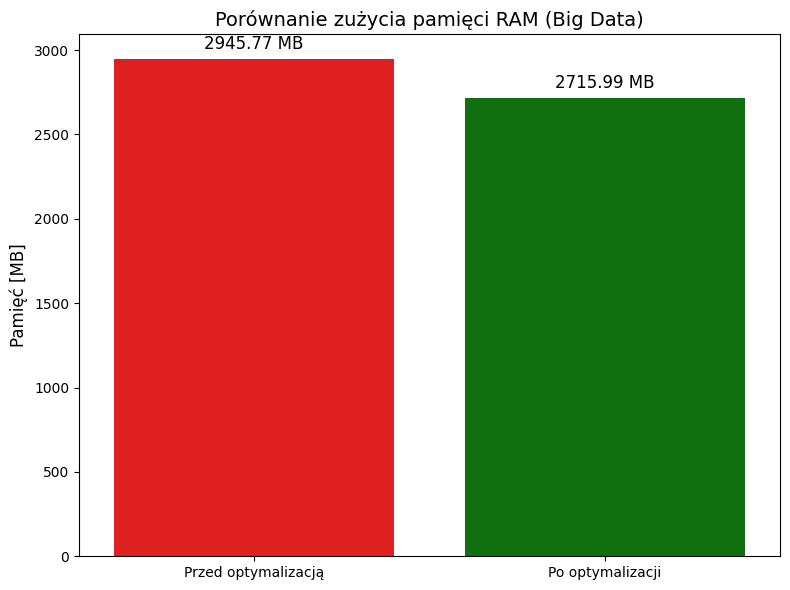


Typy danych po optymalizacji:
sid                    int32
sid_profile            int32
post_id                  str
profile_id             int64
date                     str
post_type               int8
description              str
likes                  int32
comments               int32
username                 str
bio                      str
following              int32
followers              int32
num_posts              int32
is_business_account     bool
lang                     str
category                 str
dtype: object


In [5]:
#zadanie 2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pamiec_stara_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)

df_optymalne = df.copy()

print("Optymalizacja")

for kolumna in df_optymalne.columns:
    typ_danych = df_optymalne[kolumna].dtype

    if str(typ_danych).startswith('int'):
        df_optymalne[kolumna] = pd.to_numeric(df_optymalne[kolumna], downcast='integer')

    elif str(typ_danych).startswith('float'):
        df_optymalne[kolumna] = pd.to_numeric(df_optymalne[kolumna], downcast='float')

    elif str(typ_danych) == 'object':
        liczba_unikalnych = df_optymalne[kolumna].nunique()
        liczba_wszystkich = len(df_optymalne)

        if liczba_unikalnych / liczba_wszystkich < 0.5:
            df_optymalne[kolumna] = df_optymalne[kolumna].astype('category')


pamiec_nowa_mb = df_optymalne.memory_usage(deep=True).sum() / (1024 * 1024)


print(f"Stare zużycie pamięci: {pamiec_stara_mb:.2f} MB")
print(f"Nowe zużycie pamięci:  {pamiec_nowa_mb:.2f} MB")
procent_oszczednosci = (1 - (pamiec_nowa_mb / pamiec_stara_mb)) * 100
print(f"Udało się zaoszczędzić: {pamiec_stara_mb - pamiec_nowa_mb:.2f} MB ({procent_oszczednosci:.2f}%)")


plt.figure(figsize=(8, 6))

kategorie = ['Przed optymalizacją', 'Po optymalizacji']
wartosci = [pamiec_stara_mb, pamiec_nowa_mb]

sns.barplot(x=kategorie, y=wartosci, hue=kategorie, palette=['red', 'green'])

plt.title('Porównanie zużycia pamięci RAM (Big Data)', fontsize=14)
plt.ylabel('Pamięć [MB]', fontsize=12)

for i, wartosc in enumerate(wartosci):
    plt.text(i, wartosc + (max(wartosci)*0.02), f"{wartosc:.2f} MB", ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print("\nTypy danych po optymalizacji:")
print(df_optymalne.dtypes)

In [7]:
import time

def mierz_czas(operacja):
    start = time.time()
    operacja()
    koniec = time.time()
    return koniec - start

print("Rozpoczynam testy wydajności (to może chwilę potrwać)...")

kol_numeryczna = 'likes' if 'likes' in df.columns else df.select_dtypes(include='number').columns[0]

czas_op1_stara = mierz_czas(lambda: df[kol_numeryczna].sum())
czas_op1_nowa  = mierz_czas(lambda: df_optymalne[kol_numeryczna].sum())

czas_op2_stara = mierz_czas(lambda: df[df[kol_numeryczna] > 10])
czas_op2_nowa  = mierz_czas(lambda: df_optymalne[df_optymalne[kol_numeryczna] > 10])

kolumny_kat = df_optymalne.select_dtypes(include=['category', 'object', 'str']).columns

if len(kolumny_kat) > 0:
    kol_grupujaca = kolumny_kat[0]
    czas_op3_stara = mierz_czas(lambda: df.groupby(kol_grupujaca)[kol_numeryczna].mean())
    czas_op3_nowa  = mierz_czas(lambda: df_optymalne.groupby(kol_grupujaca)[kol_numeryczna].mean())
else:
    kol_grupujaca = kol_numeryczna
    czas_op3_stara = mierz_czas(lambda: df.groupby(kol_grupujaca).size())
    czas_op3_nowa  = mierz_czas(lambda: df_optymalne.groupby(kol_grupujaca).size())


print(f"1. Sumowanie kolumny '{kol_numeryczna}':")
print(f"   Przed: {czas_op1_stara:.5f} s")
print(f"   Po:    {czas_op1_nowa:.5f} s")

print(f"\n2. Filtrowanie gdzie '{kol_numeryczna}' > 10:")
print(f"   Przed: {czas_op2_stara:.5f} s")
print(f"   Po:    {czas_op2_nowa:.5f} s")

print(f"\n3. Grupowanie po '{kol_grupujaca}' i liczenie średniej:")
print(f"   Przed: {czas_op3_stara:.5f} s")
print(f"   Po:    {czas_op3_nowa:.5f} s")

Rozpoczynam testy wydajności (to może chwilę potrwać)...

--- WYNIKI (Czas wykonania w sekundach) ---
1. Sumowanie kolumny 'likes':
   Przed: 0.00551 s
   Po:    0.00600 s

2. Filtrowanie (gdzie 'likes' > 10):
   Przed: 1.64963 s
   Po:    1.61989 s

3. Grupowanie po 'post_id' i liczenie średniej:
   Przed: 6.71180 s
   Po:    6.66158 s


In [9]:
#zadanie 4
df_optymalne.to_csv('wynik_koncowy.csv', index=False)

Plik 'wynik_koncowy.csv' został zapisany pomyślnie!


In [ ]:
#zadanie 5
import pandas as pd
import time
import os
import multiprocessing
from multiprocessing import Pool

plik_glowny = 'wynik_koncowy.csv'

katalog_podzialu = 'podzielone_pliki'
os.makedirs(katalog_podzialu, exist_ok=True)

df_baza = pd.read_csv(plik_glowny)
liczba_kawalkow = 8
rozmiar_kawalka = len(df_baza) // liczba_kawalkow
pliki_podzielone = []

print("Dzielenie pliku głównego na mniejsze kawałki")
for i in range(liczba_kawalkow):
    start_idx = i * rozmiar_kawalka
    end_idx = (i + 1) * rozmiar_kawalka if i < liczba_kawalkow - 1 else len(df_baza)

    nazwa_pliku = f"{katalog_podzialu}/czesc_{i}.csv"
    df_baza.iloc[start_idx:end_idx].to_csv(nazwa_pliku, index=False)
    pliki_podzielone.append(nazwa_pliku)

del df_baza
print("Testy\n")

def mierz_czas(operacja):
    start = time.time()
    wynik = operacja()
    koniec = time.time()
    return koniec - start, wynik


def wczytaj_pojedynczy_plik(sciezka):
    return pd.read_csv(sciezka)

def test_multiprocessing(liczba_procesow):
    with Pool(processes=liczba_procesow) as pool:
        ramki = pool.map(wczytaj_pojedynczy_plik, pliki_podzielone)
    return pd.concat(ramki, ignore_index=True)


if __name__ == '__main__':

    czas_calosc, _ = mierz_czas(lambda: pd.read_csv(plik_glowny))
    print(f"1. Wczytywanie całego pliku naraz: {czas_calosc:.4f} s")


    def wczytywanie_chunkami():
        lista_chunkow = []
        for chunk in pd.read_csv(plik_glowny, chunksize=100000):
            lista_chunkow.append(chunk)
        return pd.concat(lista_chunkow, ignore_index=True)

    czas_chunk, _ = mierz_czas(wczytywanie_chunkami)
    print(f"2. Wczytywanie w kawałkach : {czas_chunk:.4f} s")


    ilosc_rdzeni = multiprocessing.cpu_count()
    print(f"\nTwój procesor ma rdzeni logicznych: {ilosc_rdzeni}")

    procesy_1 = max(1, ilosc_rdzeni - 2)
    procesy_2 = max(1, (ilosc_rdzeni - 2) * 2)

    czas_multi_1, _ = mierz_czas(lambda: test_multiprocessing(procesy_1))
    print(f"3a. Multiprocessing {procesy_1} procesów: {czas_multi_1:.4f} s")

    czas_multi_2, _ = mierz_czas(lambda: test_multiprocessing(procesy_2))
    print(f"3b. Multiprocessing {procesy_2} procesów: {czas_multi_2:.4f} s")

    #ponad 25minut 'mielenia' i zadanie sie dalej sie nie wykonało